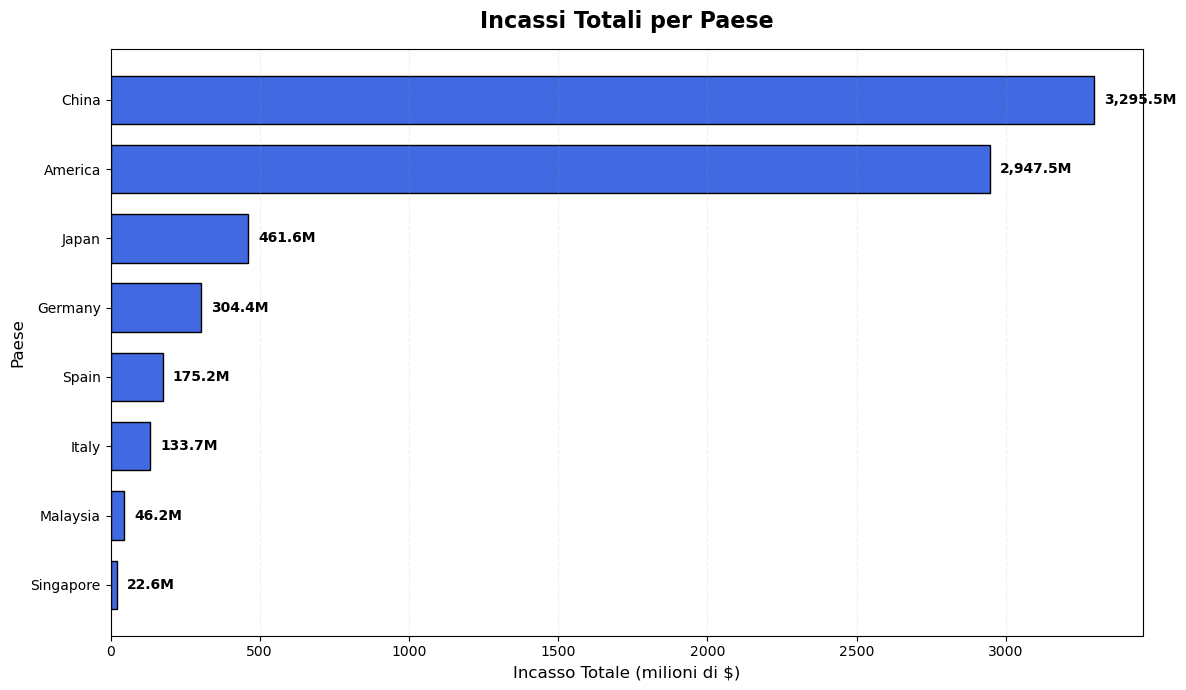

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Carica i dati
df = pd.read_csv('Nazione - Foglio1 (1).csv', skiprows=1)
df = df.set_index('Nome film')

# Converti i valori
def convert_value(x):
    if x == '-':
        return 0
    elif isinstance(x, str):
        return float(x.replace('$', '').replace(',', ''))
    return float(x)

df_numeric = df.map(convert_value)

# Calcola incassi totali per paese
incassi_totali = df_numeric.sum()
incassi_totali = incassi_totali.sort_values(ascending=True)  # Ordina
incassi_totali_milioni = incassi_totali / 1000000  # Converti in milioni

# Crea l'istogramma orizzontale
plt.figure(figsize=(12, 7))

bars = plt.barh(incassi_totali_milioni.index, incassi_totali_milioni.values, 
                color='royalblue', edgecolor='black', height=0.7)

# Aggiungi valori sulle barre
for i, (paese, valore) in enumerate(zip(incassi_totali_milioni.index, incassi_totali_milioni.values)):
    plt.text(valore + max(incassi_totali_milioni.values) * 0.01, i, 
             f'{valore:,.1f}M', va='center', fontsize=10, fontweight='bold')

# Personalizza
plt.title('Incassi Totali per Paese', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Incasso Totale (milioni di $)', fontsize=12)
plt.ylabel('Paese', fontsize=12)
plt.grid(axis='x', alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()